<a href="https://colab.research.google.com/github/cysorianoc/Hugging_Face/blob/main/Notebook_10_image_captioning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 10: Image Captioning

For image captioning task we ask the model to return the description of an image.


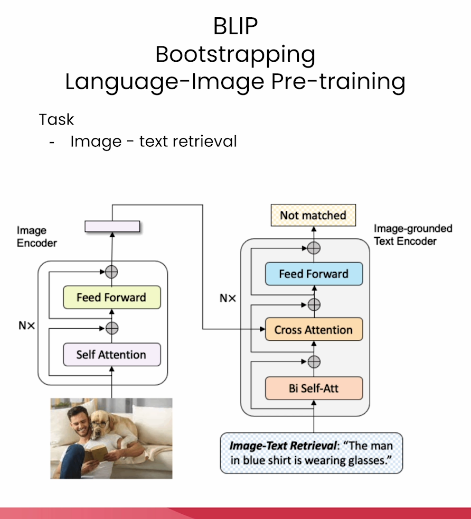

- In the classroom, the libraries are already installed for you.
- If you would like to run this code on your own machine, you can install the following:

```
    !pip install transformers
```

- Here is some code that suppresses warning messages.

In [1]:
from transformers.utils import logging
logging.set_verbosity_error()

import warnings
warnings.filterwarnings("ignore", message="Using the model-agnostic default `max_length`")

- Load the Model and the Processor.

In [2]:
from transformers import BlipForConditionalGeneration

In [3]:
model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base")

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  990MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

Info about [Salesforce/blip-image-captioning-base](https://huggingface.co/Salesforce/blip-image-captioning-base)

In [4]:
# We also need to import the processor
from transformers import AutoProcessor

In [5]:
processor = AutoProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

- Load the image.

In [6]:
from PIL import Image
from io import BytesIO
import requests

In [7]:
image_url="https://raw.githubusercontent.com/cysorianoc/Hugging_Face/main/beach.jpeg"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))

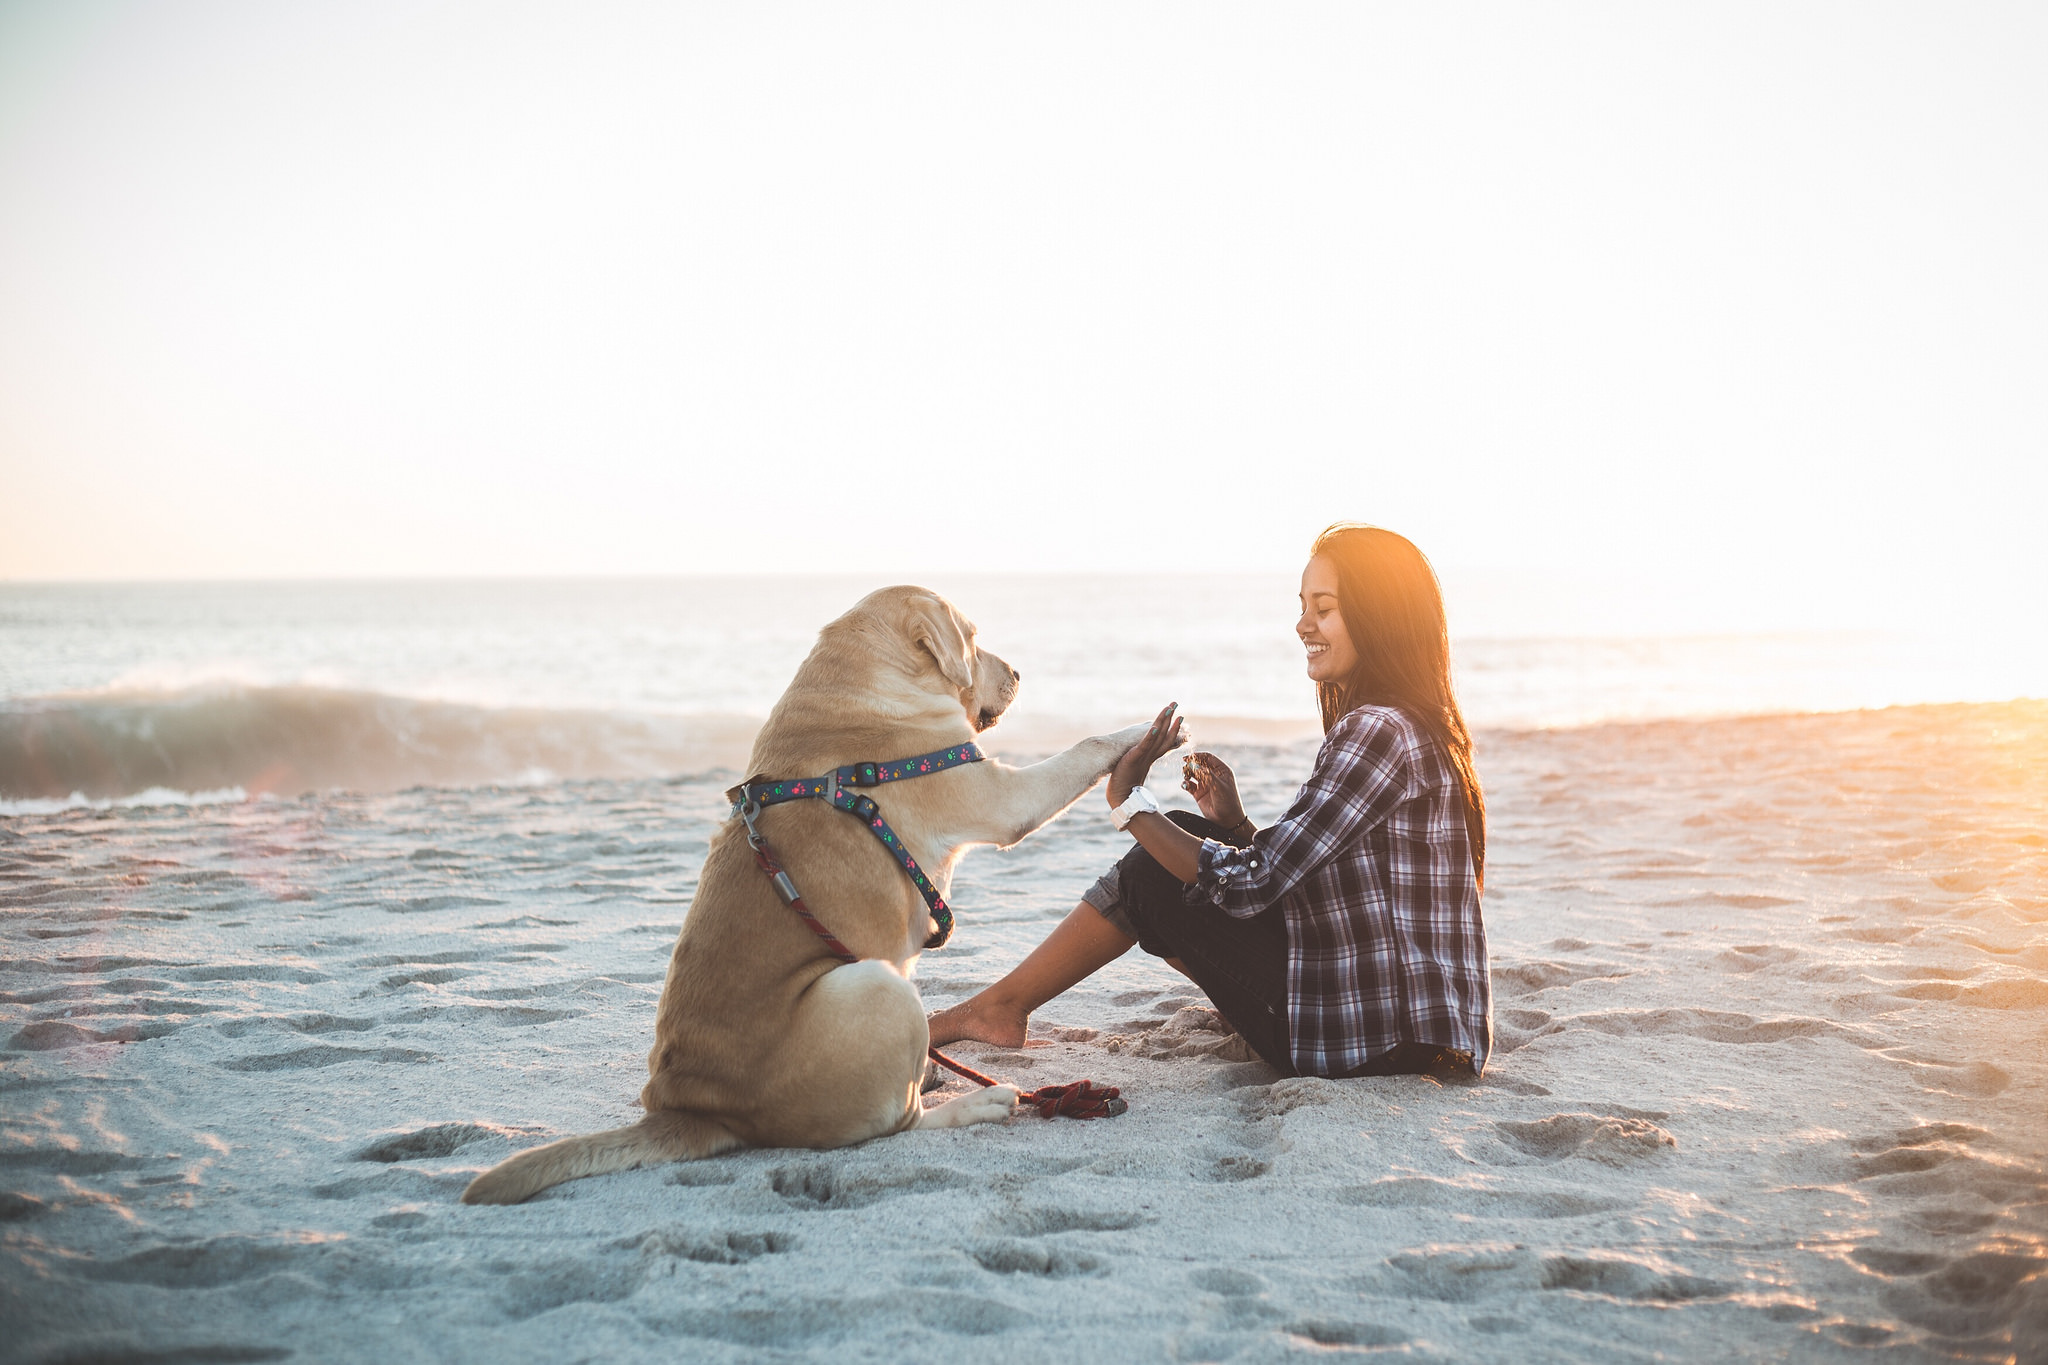

In [8]:
image

### Conditional Image Captioning

In [9]:
text = "a photograph of"
inputs = processor(image, text, return_tensors="pt")

In [10]:
inputs

{'input_ids': tensor([[ 101, 1037, 9982, 1997,  102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1]]), 'pixel_values': tensor([[[[ 0.8647,  0.9230,  0.9376,  ...,  1.7552,  1.7552,  1.7552],
          [ 0.9084,  0.9376,  0.9522,  ...,  1.7552,  1.7552,  1.7552],
          [ 0.9376,  0.9376,  0.9668,  ...,  1.7552,  1.7552,  1.7552],
          ...,
          [-0.7850, -0.7850, -0.7266,  ..., -0.3178, -0.2740, -0.3616],
          [-0.7558, -0.7558, -0.7412,  ..., -0.3178, -0.3616, -0.4346],
          [-0.7558, -0.7704, -0.7850,  ..., -0.3616, -0.4346, -0.4784]],

         [[ 1.2194,  1.2495,  1.2795,  ...,  1.8948,  1.8948,  1.8948],
          [ 1.2344,  1.2645,  1.2945,  ...,  1.8948,  1.8948,  1.8948],
          [ 1.2495,  1.2795,  1.3095,  ...,  1.8948,  1.8948,  1.8948],
          ...,
          [-0.5965, -0.5965, -0.5515,  ..., -0.4014, -0.3264, -0.4164],
          [-0.5665, -0.5665, -0.5515,  ..., -0.3864, -0.4164, -0.4914],
          [-0.5665, -0.5815, -0.5965,  ..., -0.4164, -0.476

In [11]:
out = model.generate(**inputs)

In [12]:
out

tensor([[30522,  1037,  9982,  1997,  1037,  2450,  1998,  2014,  3899,  2006,
          1996,  3509,   102]])

In [13]:
print(processor.decode(out[0], skip_special_tokens=True))

a photograph of a woman and her dog on the beach


### Unconditional Image Captioning

In [14]:
inputs = processor(image,return_tensors="pt")

In [15]:
out = model.generate(**inputs)

In [16]:
print(processor.decode(out[0], skip_special_tokens=True))

a woman sitting on the beach with her dog


### Try it yourself!
- Try this model with your own images and texts!

In [32]:
image_2_url="https://images.unsplash.com/photo-1650625751957-82207de3663a?q=80&w=1171&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
response_2= requests.get(image_2_url)
image_2= Image.open(BytesIO(response_2.content))

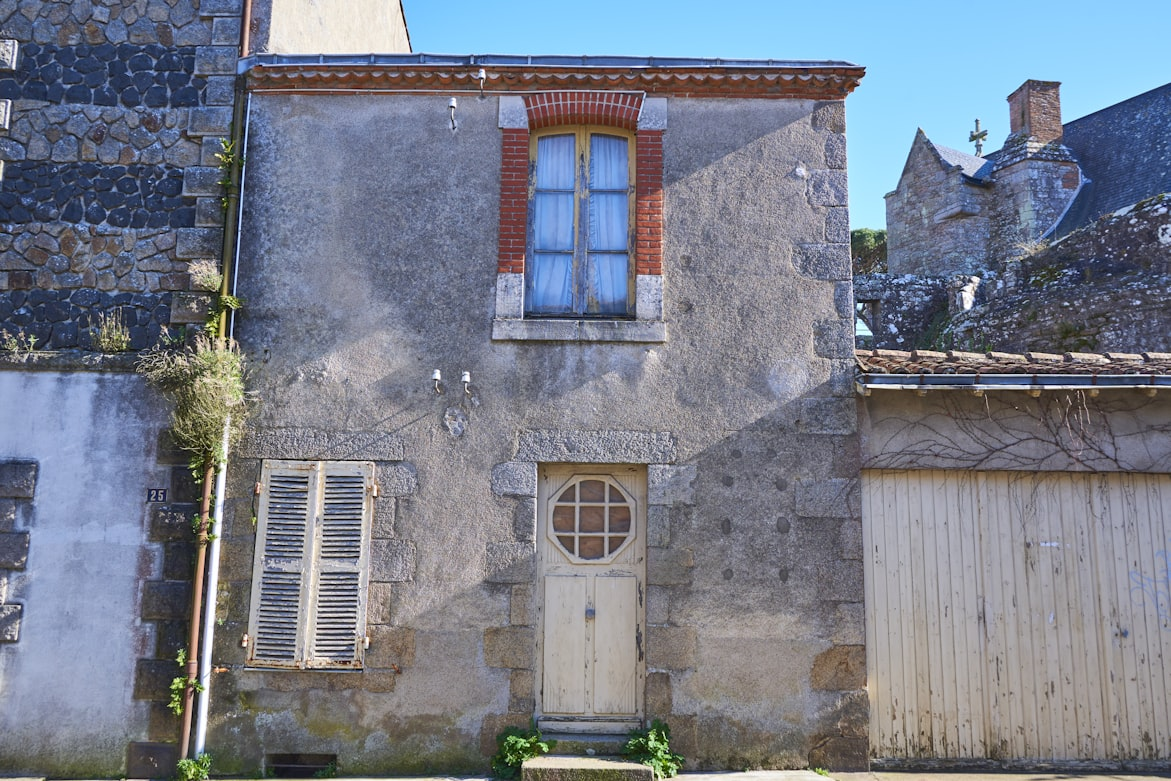

In [33]:
image_2

In [34]:
inputs = processor(image_2,return_tensors="pt")

In [35]:
out = model.generate(**inputs)

In [36]:
print(processor.decode(out[0], skip_special_tokens=True))

a small house with a door and windows
